# Calibration Baseline Drift

Purpose: inspect empty-room amplitude/phase baseline calibration, per-frame deviation scoring, and sustained baseline drift warnings for Milestone 6.

Run path: install research extras with `uv sync --extra research`, open this notebook, and choose Run All. The notebook is deterministic and does not require radio hardware.

Fixture / simulated source: `make_calibration_fixture` creates HT20-style active-subcarrier CSI with a 600-frame empty-room calibration period, a gradual post-calibration amplitude/phase drift, and a localized person/motion perturbation event. Guarded imports from `ruview.ruvsense.calibration` are probed when available; local NumPy helpers keep the notebook runnable while the Python port is still landing.


In [1]:
import numpy as np

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError('Install the research extra with: uv sync --extra research') from exc

try:
    from ruview.ruvsense import calibration as calibration_api
except Exception as exc:
    calibration_api = None
    CALIBRATION_IMPORT_ERROR = exc
else:
    CALIBRATION_IMPORT_ERROR = None

plt.rcParams.update({
    'figure.figsize': (11, 4.6),
    'axes.grid': True,
    'grid.alpha': 0.25,
})


In [2]:
def make_calibration_fixture(
    *,
    frames=960,
    subcarriers=52,
    sample_rate_hz=20.0,
    calibration_frames=600,
    seed=135,
):
    rng = np.random.default_rng(seed)
    time_s = np.arange(frames, dtype=float) / sample_rate_hz
    subcarrier_axis = np.linspace(-1.0, 1.0, subcarriers)
    calibration_end_s = calibration_frames / sample_rate_hz

    base_amplitude = (
        0.72
        + 0.24 * np.sin(0.5 * np.pi * (subcarrier_axis + 1.0)) ** 2
        + 0.05 * np.cos(3.0 * np.pi * subcarrier_axis)
    )
    base_phase = 0.22 * np.sin(1.7 * np.pi * subcarrier_axis) + 0.04 * subcarrier_axis

    drift_progress = np.clip((time_s - calibration_end_s) / 18.0, 0.0, 1.0)
    drift_shape = 0.65 + 0.35 * np.cos(np.pi * subcarrier_axis - 0.4)
    amplitude_drift = 0.12 * drift_progress[:, None] * drift_shape[None, :]
    phase_drift = 0.16 * drift_progress[:, None] * np.sin(2.0 * np.pi * subcarrier_axis)[None, :]

    event_center_s = calibration_end_s + 7.2
    event_sigma_s = 1.1
    event_envelope = np.exp(-0.5 * ((time_s - event_center_s) / event_sigma_s) ** 2)
    event_band = np.exp(-0.5 * ((subcarrier_axis - 0.18) / 0.16) ** 2)
    motion_ripple = 1.0 + 0.30 * np.sin(2.0 * np.pi * 1.6 * time_s)
    amplitude_event = 0.22 * event_envelope[:, None] * event_band[None, :] * motion_ripple[:, None]
    phase_event = 0.35 * event_envelope[:, None] * np.sin(5.0 * np.pi * subcarrier_axis)[None, :]

    amplitude_noise = rng.normal(0.0, 0.006, size=(frames, subcarriers))
    phase_noise = rng.normal(0.0, 0.008, size=(frames, subcarriers))
    amplitude = np.clip(base_amplitude[None, :] + amplitude_drift + amplitude_event + amplitude_noise, 0.02, None)
    phase = base_phase[None, :] + phase_drift + phase_event + phase_noise
    csi = amplitude * np.exp(1j * phase)

    return {
        'csi': csi,
        'amplitude': amplitude,
        'phase': phase,
        'time_s': time_s,
        'subcarrier_axis': subcarrier_axis,
        'sample_rate_hz': sample_rate_hz,
        'calibration_frames': calibration_frames,
        'calibration_end_s': calibration_end_s,
        'event_center_s': event_center_s,
        'event_window_s': (event_center_s - 2.0 * event_sigma_s, event_center_s + 2.0 * event_sigma_s),
        'drift_progress': drift_progress,
    }


fixture = make_calibration_fixture()
available_api_symbols = [] if calibration_api is None else [
    name for name in (
        'CalibrationConfig',
        'CalibrationRecorder',
        'BaselineCalibration',
        'CalibrationDeviationScore',
    ) if hasattr(calibration_api, name)
]

fixture_summary = {
    'csi_shape': fixture['csi'].shape,
    'calibration_frames': fixture['calibration_frames'],
    'calibration_duration_s': fixture['calibration_end_s'],
    'event_window_s': tuple(round(value, 2) for value in fixture['event_window_s']),
    'calibration_api_available': calibration_api is not None,
    'calibration_api_symbols': available_api_symbols,
}

fixture_summary


{'csi_shape': (960, 52),
 'calibration_frames': 600,
 'calibration_duration_s': 30.0,
 'event_window_s': (35.0, 39.4),
 'calibration_api_available': True,
 'calibration_api_symbols': ['CalibrationConfig',
  'CalibrationRecorder',
  'BaselineCalibration',
  'CalibrationDeviationScore']}

In [3]:
def circular_distance(a, b):
    distance = np.abs(a - b)
    return np.where(distance > np.pi, 2.0 * np.pi - distance, distance)


def rolling_median(values, window):
    result = np.empty_like(values, dtype=float)
    for index in range(values.shape[0]):
        start = max(0, index - window + 1)
        result[index] = np.median(values[start:index + 1], axis=0)
    return result


def measure_empty_room_baseline(csi, calibration_frames):
    amplitude = np.abs(csi)
    phase = np.angle(csi)
    calibration_amplitude = amplitude[:calibration_frames]
    calibration_phase = phase[:calibration_frames]

    sin_mean = np.sin(calibration_phase).mean(axis=0)
    cos_mean = np.cos(calibration_phase).mean(axis=0)
    resultant_length = np.sqrt(sin_mean ** 2 + cos_mean ** 2)

    return {
        'amp_mean': calibration_amplitude.mean(axis=0),
        'amp_variance': calibration_amplitude.var(axis=0, ddof=1),
        'phase_mean': np.arctan2(sin_mean, cos_mean),
        'phase_dispersion': 1.0 - np.minimum(resultant_length, 1.0),
        'frame_count': calibration_frames,
    }


def deviation_against_baseline(csi, baseline, *, drift_window=300):
    amplitude = np.abs(csi)
    phase = np.angle(csi)
    amp_std = np.sqrt(np.maximum(baseline['amp_variance'], 1e-12))
    z_scores = (amplitude - baseline['amp_mean'][None, :]) / amp_std[None, :]
    phase_drift = circular_distance(phase, baseline['phase_mean'][None, :])
    z_squared_median = rolling_median(z_scores ** 2, drift_window)
    calibrated_amplitude = np.maximum(amplitude - baseline['amp_mean'][None, :], 0.0)

    return {
        'z_scores': z_scores,
        'phase_drift': phase_drift,
        'amplitude_z_median': np.median(np.abs(z_scores), axis=1),
        'amplitude_z_max': np.max(np.abs(z_scores), axis=1),
        'phase_drift_median': np.median(phase_drift, axis=1),
        'motion_flagged': (np.median(np.abs(z_scores), axis=1) > 2.0)
        | (np.median(phase_drift, axis=1) > np.pi / 6.0),
        'drift_score': z_squared_median.mean(axis=1),
        'calibrated_amplitude': calibrated_amplitude,
    }


baseline = measure_empty_room_baseline(fixture['csi'], fixture['calibration_frames'])
deviation = deviation_against_baseline(fixture['csi'], baseline)

time_s = fixture['time_s']
post_calibration = time_s >= fixture['calibration_end_s']
drift_threshold = 4.0
drift_candidates = np.flatnonzero(post_calibration & (deviation['drift_score'] > drift_threshold))
event_frame = int(np.argmin(np.abs(time_s - fixture['event_center_s'])))
first_drift_frame = int(drift_candidates[0]) if drift_candidates.size else None

analysis_summary = {
    'baseline_frame_count': baseline['frame_count'],
    'median_baseline_amp_std': round(float(np.median(np.sqrt(baseline['amp_variance']))), 5),
    'median_phase_dispersion': round(float(np.median(baseline['phase_dispersion'])), 6),
    'event_frame_time_s': round(float(time_s[event_frame]), 2),
    'first_drift_marker_s': None if first_drift_frame is None else round(float(time_s[first_drift_frame]), 2),
    'max_drift_score': round(float(np.max(deviation['drift_score'])), 2),
}

analysis_summary


{'baseline_frame_count': 600,
 'median_baseline_amp_std': 0.00593,
 'median_phase_dispersion': 3.2e-05,
 'event_frame_time_s': 37.2,
 'first_drift_marker_s': 39.85,
 'max_drift_score': 92.63}

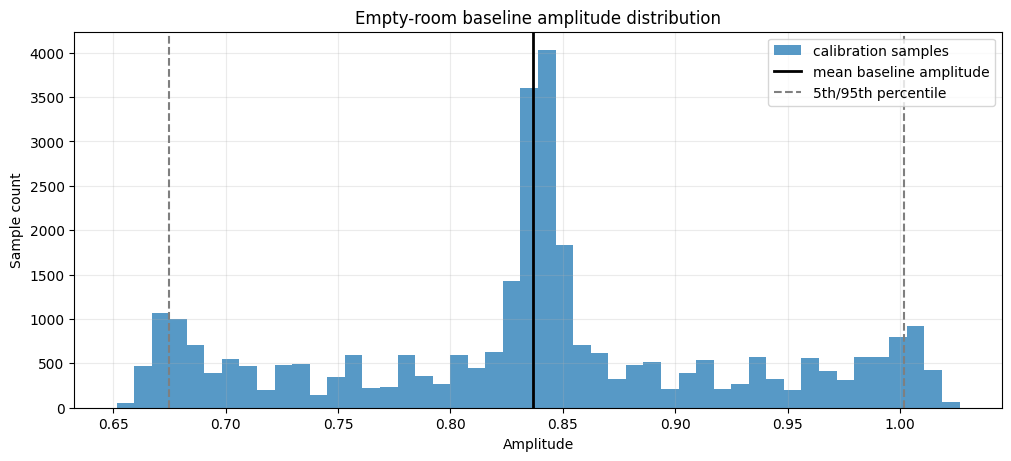

In [4]:
calibration_amplitude = fixture['amplitude'][:fixture['calibration_frames']]

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
ax.hist(calibration_amplitude.ravel(), bins=48, color='tab:blue', alpha=0.75, label='calibration samples')
ax.axvline(float(np.mean(baseline['amp_mean'])), color='black', linewidth=2, label='mean baseline amplitude')
ax.axvline(float(np.percentile(calibration_amplitude, 5)), color='tab:gray', linestyle='--', label='5th/95th percentile')
ax.axvline(float(np.percentile(calibration_amplitude, 95)), color='tab:gray', linestyle='--')
ax.set_title('Empty-room baseline amplitude distribution')
ax.set_xlabel('Amplitude')
ax.set_ylabel('Sample count')
ax.legend(loc='upper right')
plt.show()


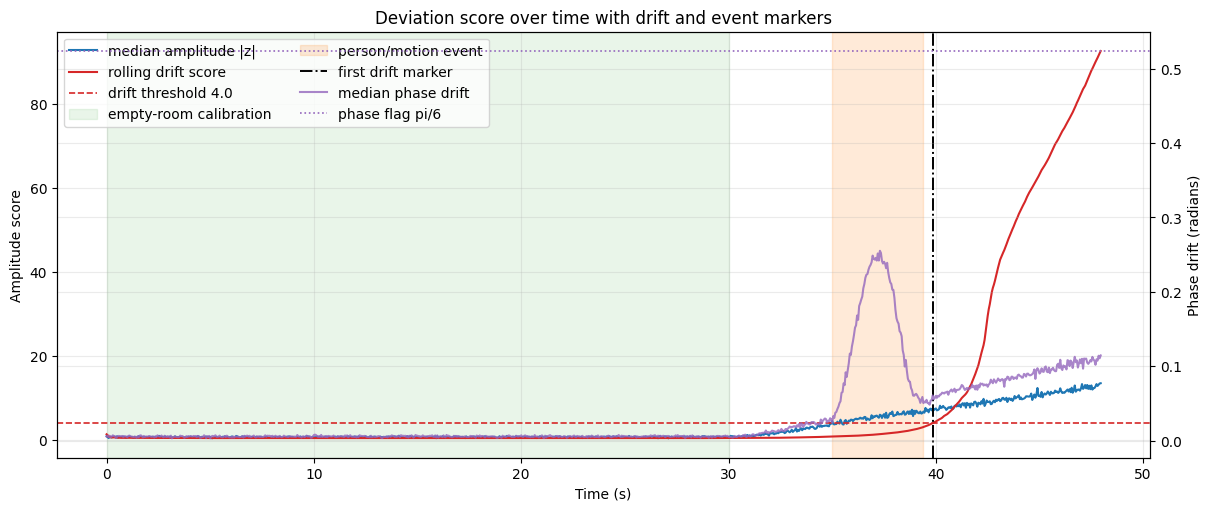

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax2 = ax1.twinx()

ax1.plot(time_s, deviation['amplitude_z_median'], color='tab:blue', label='median amplitude |z|')
ax1.plot(time_s, deviation['drift_score'], color='tab:red', label='rolling drift score')
ax1.axhline(drift_threshold, color='tab:red', linestyle='--', linewidth=1.2, label='drift threshold 4.0')
ax2.plot(time_s, deviation['phase_drift_median'], color='tab:purple', alpha=0.8, label='median phase drift')
ax2.axhline(np.pi / 6.0, color='tab:purple', linestyle=':', linewidth=1.2, label='phase flag pi/6')

ax1.axvspan(time_s[0], fixture['calibration_end_s'], color='tab:green', alpha=0.10, label='empty-room calibration')
ax1.axvspan(*fixture['event_window_s'], color='tab:orange', alpha=0.16, label='person/motion event')
if first_drift_frame is not None:
    ax1.axvline(time_s[first_drift_frame], color='black', linestyle='-.', linewidth=1.4, label='first drift marker')

ax1.set_title('Deviation score over time with drift and event markers')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude score')
ax2.set_ylabel('Phase drift (radians)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', ncols=2)
plt.show()


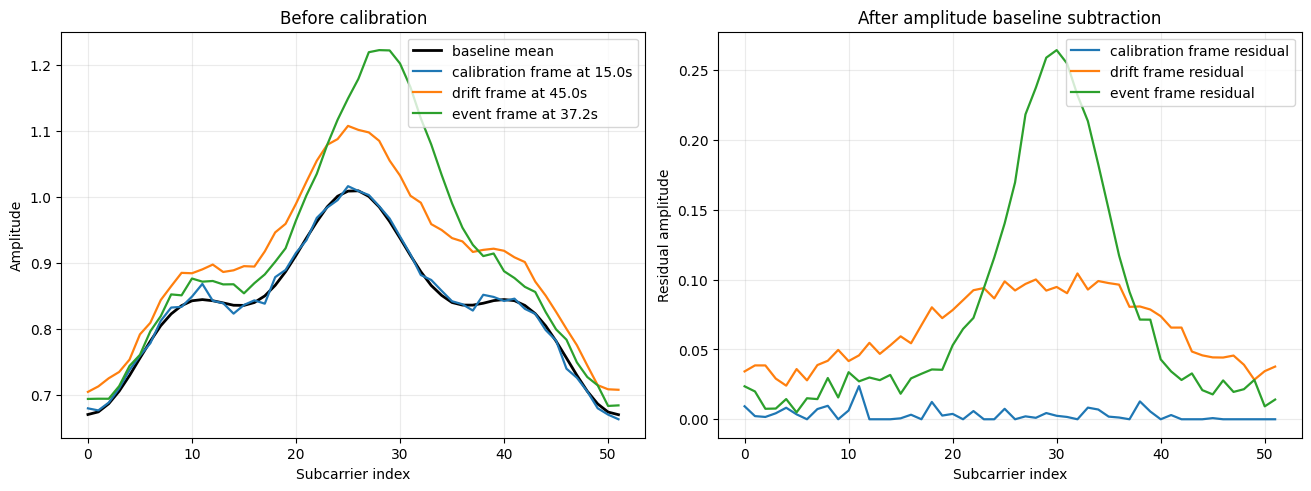

In [6]:
selected_frames = {
    'calibration frame': fixture['calibration_frames'] // 2,
    'drift frame': int(np.argmin(np.abs(time_s - (fixture['calibration_end_s'] + 15.0)))),
    'event frame': event_frame,
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
subcarrier_index = np.arange(fixture['csi'].shape[1])

axes[0].plot(subcarrier_index, baseline['amp_mean'], color='black', linewidth=2.0, label='baseline mean')
for label, frame_index in selected_frames.items():
    axes[0].plot(subcarrier_index, fixture['amplitude'][frame_index], linewidth=1.6, label=f'{label} at {time_s[frame_index]:.1f}s')
axes[0].set_title('Before calibration')
axes[0].set_xlabel('Subcarrier index')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

for label, frame_index in selected_frames.items():
    axes[1].plot(subcarrier_index, deviation['calibrated_amplitude'][frame_index], linewidth=1.6, label=f'{label} residual')
axes[1].set_title('After amplitude baseline subtraction')
axes[1].set_xlabel('Subcarrier index')
axes[1].set_ylabel('Residual amplitude')
axes[1].legend(loc='upper right')

plt.show()


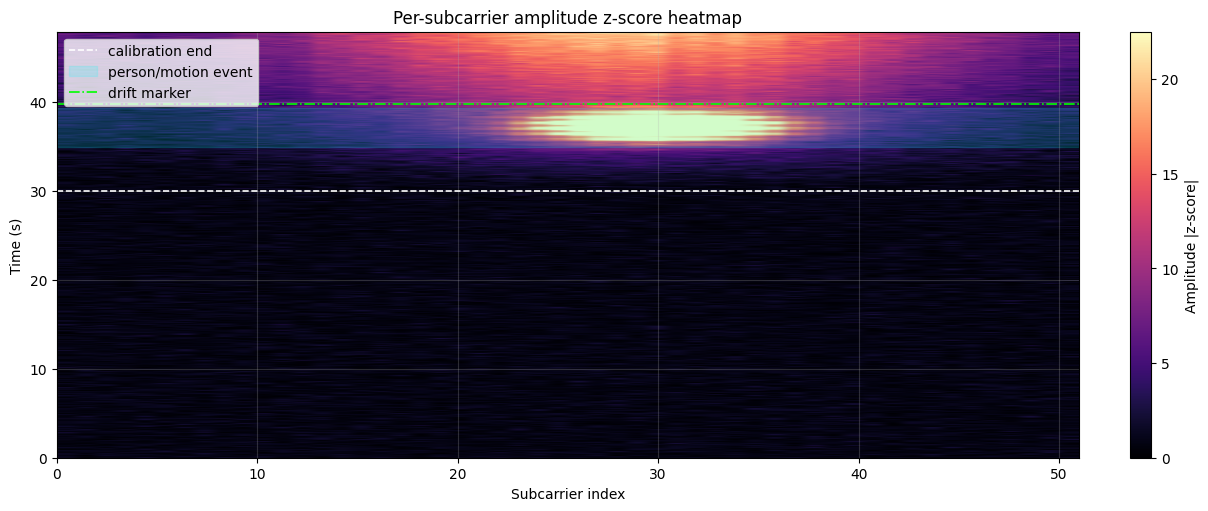

In [7]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
extent = [0, fixture['csi'].shape[1] - 1, time_s[0], time_s[-1]]
z_abs = np.abs(deviation['z_scores'])
z_cap = float(np.percentile(z_abs, 99))
image = ax.imshow(z_abs, aspect='auto', origin='lower', extent=extent, cmap='magma', vmin=0.0, vmax=z_cap)
ax.axhline(fixture['calibration_end_s'], color='white', linestyle='--', linewidth=1.2, label='calibration end')
ax.axhspan(*fixture['event_window_s'], color='cyan', alpha=0.16, label='person/motion event')
if first_drift_frame is not None:
    ax.axhline(time_s[first_drift_frame], color='lime', linestyle='-.', linewidth=1.2, label='drift marker')
ax.set_title('Per-subcarrier amplitude z-score heatmap')
ax.set_xlabel('Subcarrier index')
ax.set_ylabel('Time (s)')
fig.colorbar(image, ax=ax, label='Amplitude |z-score|')
ax.legend(loc='upper left')
plt.show()


Expected interpretation: the calibration histogram should be narrow because the first 600 frames are empty-room samples. Median amplitude z-score and phase drift should stay low during calibration, the localized person/motion event should produce a short high-z band near the event subcarriers, and the gradual post-calibration drift should eventually cross the rolling drift-score threshold. The before/after plot should show static room amplitude largely removed while drift and event residuals remain visible.

Limitations: this is a research visualization, not the production calibration engine. The local helpers approximate the Rust ADR-135 behavior with NumPy arrays and do not serialize the little-endian binary ABI, persist TOML/NVS baselines, enforce PHY tier mismatches, run `phase_sanitizer.rs`/`phase_align.rs`, model packet loss or AGC changes, or compute the ADR-030 SVD field model. Guarded imports report whether `ruview.ruvsense.calibration` is available, but the notebook keeps the fallback path as the stable runnable fixture until the Python API shape is final.
